# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [15]:
df = pd.read_csv("/content/student_lifestyle_performance_dataset.csv")

usecols = ['Age', 'Screen_Time_Hours', 'Gym_Hours_per_Week', 'Study_Hours_per_Day', 'Sleep_Hours']

df_sorted = df.sort_values(by='CGPA', ascending=False)

chosen = df_sorted.loc[:, usecols]

chosen.head(15)

,Age,Screen_Time_Hours,Gym_Hours_per_Week,Study_Hours_per_Day,Sleep_Hours
657,22,3.84,12.67,6.85,8.45
109,23,7.19,6.05,5.83,9.26
843,24,3.28,3.59,4.64,8.34
405,17,2.21,18.13,6.87,7.92
464,25,7.92,7.85,5.18,9.13
171,20,6.46,0.00,8.05,7.34
475,19,2.98,12.96,5.71,8.07
639,19,3.96,8.24,7.30,8.57
659,20,7.14,5.21,3.85,9.22
682,25,4.95,0.00,4.87,8.25


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [18]:
chosen['Leisure_Time'] = 24 - (chosen['Study_Hours_per_Day'] + chosen['Sleep_Hours'] + (chosen['Screen_Time_Hours'] - 1) + (chosen['Gym_Hours_per_Week'] / 7) + 2.5)

chosen['Leisure_Time'] = chosen['Leisure_Time'].round(2)

used_cols = ['Leisure_Time', 'Screen_Time_Hours', 'Gym_Hours_per_Week', 'Study_Hours_per_Day', 'Sleep_Hours']

leisure_time = chosen.loc[:, used_cols]
leisure_time

,Leisure_Time,Screen_Time_Hours,Gym_Hours_per_Week,Study_Hours_per_Day,Sleep_Hours
657,1.55,3.84,12.67,6.85,8.45
109,-0.64,7.19,6.05,5.83,9.26
843,5.73,3.28,3.59,4.64,8.34
405,2.91,2.21,18.13,6.87,7.92
464,-0.85,7.92,7.85,5.18,9.13
...,...,...,...,...,...
518,7.40,6.10,8.62,3.25,4.52
135,10.95,5.82,2.16,2.42,3.00
361,15.64,2.05,0.00,0.66,4.15
776,14.92,1.83,5.01,0.70,4.33


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [20]:
df_of_age = df[df['Age'] >= 18]

df_conclusion = df_of_age.groupby('Branch').agg(Mean_Stress_Level=('Stress_Level_1_to_10', 'mean'), Sleep_Median=('Sleep_Hours', 'median'))

df_conclusion = df_conclusion.sort_values(by='Mean_Stress_Level', ascending=False)

df_conclusion

,Mean_Stress_Level,Sleep_Median
Branch,,
Civil,4.630494,6.710
ECE,4.626014,6.405
Mechanical,4.608940,6.640
Electrical,4.544621,6.310
CSE,4.526667,6.540
IT,4.454929,6.755


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

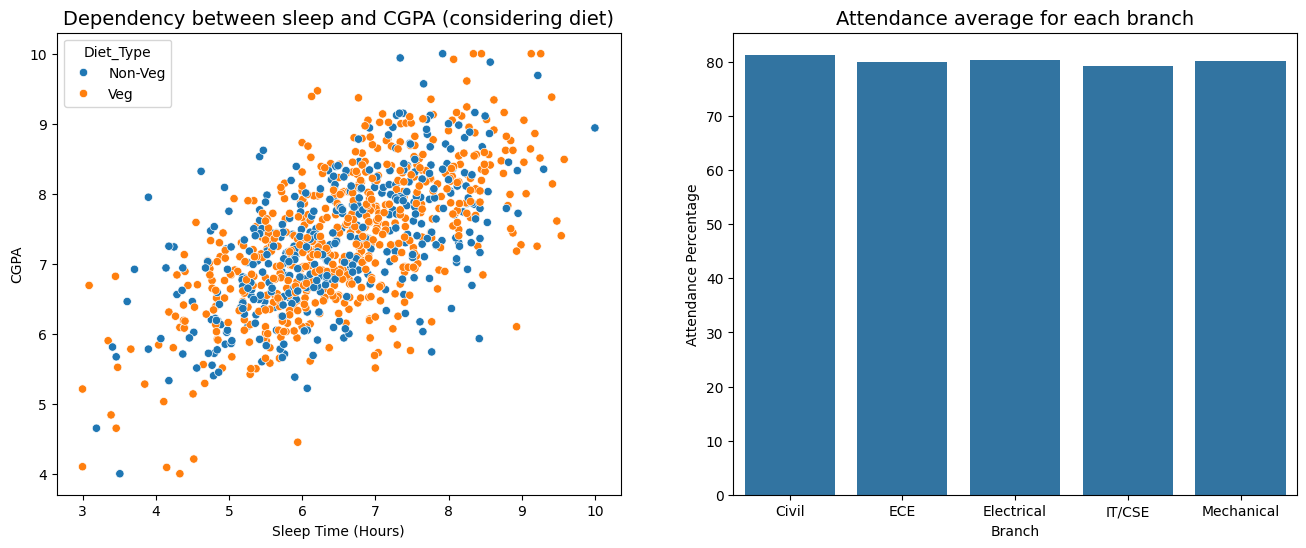

In [27]:
df['Branch'] = df['Branch'].replace({'IT': 'IT/CSE', 'CSE': 'IT/CSE'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df,
    x='Sleep_Hours',
    y='CGPA',
    hue='Diet_Type',
    ax=axes[0]
)

axes[0].set_title('Dependency between sleep and CGPA (considering diet)', fontsize=14)
axes[0].set_xlabel('Sleep Time (Hours)')
axes[0].set_ylabel('CGPA')

mean_attendance = df.groupby('Branch')['Attendance_Percentage'].mean().reset_index()

sns.barplot(
    data=mean_attendance,
    x='Branch',
    y='Attendance_Percentage',
    ax=axes[1]
)

axes[1].set_title('Attendance average for each branch', fontsize=14)
axes[1].set_xlabel('Branch')
axes[1].set_ylabel('Attendance Percentage')

plt.show()

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?